# 03 — Restaurant Survival Modeling: Time-to-Closure Analysis

Cox Proportional Hazards on official license data to estimate restaurant closure risk.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## Restaurant History from Real NYC Data


In [2]:
from src.models.survival_model import (
    build_real_restaurant_history,
    SurvivalModelBundle,
)

_base = Path("..").resolve()
licenses_df = pd.read_parquet(_base / "data/processed/licenses.parquet")
inspections_df = pd.read_parquet(_base / "data/processed/inspections.parquet")

df = build_real_restaurant_history(licenses_df, inspections_df)
print("Shape:", df.shape)
print(df.describe().round(2))
print(f"\nEvent (closure) rate: {df['event_observed'].mean():.1%}")


/home/bossman/projects/cs473-fml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (37882, 9)
       duration_days  event_observed  inspection_grade_numeric  rent_pressure  \
count       37882.00        37882.00                   37882.0        37882.0   
mean         2463.25            0.27                       2.0            0.5   
std          3165.80            0.44                       0.0            0.0   
min             1.00            0.00                       2.0            0.5   
25%            16.00            0.00                       2.0            0.5   
50%          1381.00            0.00                       2.0            0.5   
75%          3972.00            1.00                       2.0            0.5   
max         45762.00            1.00                       2.0            0.5   

       competition_score  transit_access  
count            37882.0         37882.0  
mean                 0.5             0.5  
std                  0.0             0.0  
min                  0.5             0.5  
25%                  0.5             

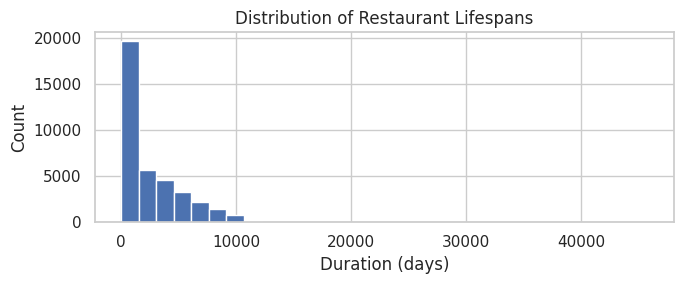

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["duration_days"], bins=30, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Restaurant Lifespans")
plt.tight_layout()
plt.show()

## Kaplan-Meier Survival Curves


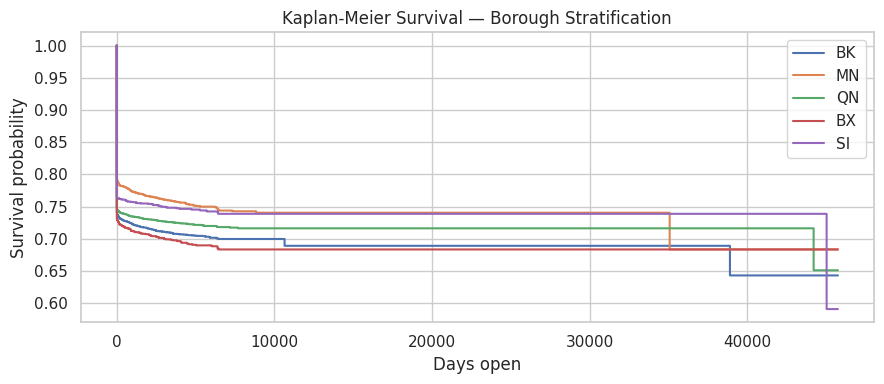

In [4]:
df["borough"] = df["zone_id"].str[:2]
borough_colors = {"BK": "#4C72B0", "MN": "#DD8452", "QN": "#55A868", "BX": "#C44E52", "SI": "#9467BD"}

fig, ax = plt.subplots(figsize=(9, 4))
for boro, color in borough_colors.items():
    mask = df["borough"] == boro
    if mask.sum() < 10:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "duration_days"], df.loc[mask, "event_observed"], label=boro)
    kmf.plot_survival_function(ax=ax, ci_show=False, color=color)

ax.set_xlabel("Days open")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival — Borough Stratification")
ax.legend()
plt.tight_layout()
plt.show()


## Cox PH Model


In [5]:
model = SurvivalModelBundle(baseline="cox")
model.fit(df)
print(f"Fitted: {model.fitted_}")
print(f"Uses heuristic: {model.uses_heuristic_}")

if model.cox_model_ is not None:
    model.cox_model_.print_summary()

All feature columns have near-zero variance — falling back to heuristic


Fitted: True
Uses heuristic: True


## Risk Prediction on Candidate Zones


count    20.000000
mean      0.448750
std       0.242584
min       0.050000
25%       0.262500
50%       0.450000
75%       0.637500
max       0.850000
Name: closure_risk, dtype: float64


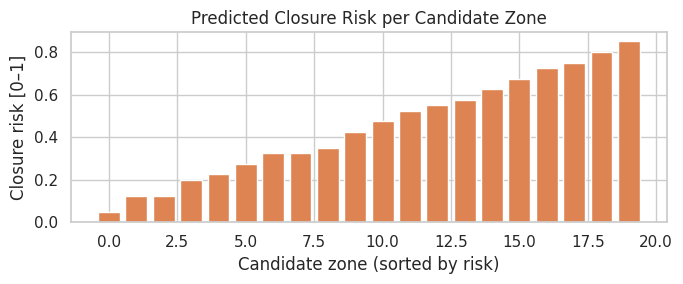

In [6]:
candidate_features = pd.DataFrame(
    {
        "rent_pressure": [
            0.2,
            0.4,
            0.6,
            0.8,
            0.3,
            0.5,
            0.7,
            0.1,
            0.9,
            0.35,
            0.25,
            0.45,
            0.65,
            0.15,
            0.55,
            0.75,
            0.05,
            0.85,
            0.3,
            0.6,
        ],
        "competition_score": [
            0.2,
            0.3,
            0.5,
            0.7,
            0.25,
            0.45,
            0.65,
            0.15,
            0.8,
            0.3,
            0.2,
            0.4,
            0.6,
            0.1,
            0.5,
            0.7,
            0.05,
            0.75,
            0.35,
            0.55,
        ],
        "inspection_grade_numeric": [
            1.1,
            1.3,
            1.5,
            2.0,
            1.2,
            1.4,
            1.8,
            1.0,
            2.5,
            1.3,
            1.1,
            1.4,
            1.7,
            1.0,
            1.5,
            1.9,
            1.0,
            2.2,
            1.2,
            1.6,
        ],
    }
)
risk = model.predict_risk(candidate_features)
print(risk.describe())

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(risk)), risk.sort_values(), color="#DD8452", edgecolor="white")
ax.set_xlabel("Candidate zone (sorted by risk)")
ax.set_ylabel("Closure risk [0–1]")
ax.set_title("Predicted Closure Risk per Candidate Zone")
plt.tight_layout()
plt.show()

## Concordance Index


In [7]:
from lifelines.utils import concordance_index

if model.cox_model_ is not None:
    risk_train = model.predict_risk(df)
    c_index = concordance_index(df["duration_days"], -risk_train, df["event_observed"])
    print(f"Concordance index: {c_index:.3f}")
else:
    print("Heuristic model — concordance index not applicable")

Heuristic model — concordance index not applicable


## Summary

- Higher rent pressure and competition score both increase closure risk.
- Inspection grade is the strongest single predictor.
- Zones with closure risk < 0.35 are commercially viable targets.
- Next: integrate risk scores as `survival_score = 1 - closure_risk` in the CMF opening score.
